In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
try:
    import pulp
except ImportError:
    !pip install pulp
    import pulp

# --- STEP 1: CREATE RETURNS DATASET ---
# Using weekly_demand_df (aggregated in previous phase)
weekly_demand_df = pd.read_csv('../data/chainos.db/base data/weekly_demand.csv')
returns_data = weekly_demand_df[['item_id', 'store_id', 'wm_yr_wk', 'weekly_sales']].copy()

# Calculate returns_qty: 3% of sales, rounded, min 0
returns_data['returns_qty'] = (returns_data['weekly_sales'] * 0.03).round().astype(int)
returns_data['returns_qty'] = np.maximum(0, returns_data['returns_qty'])

# Assign Condition Grades
grades = ['Grade A', 'Grade B', 'Grade C']
grade_probs = [0.60, 0.25, 0.15]
returns_data['condition_grade'] = np.random.choice(grades, size=len(returns_data), p=grade_probs)

# Assign Return Reasons
reasons = ['Damaged', 'Expired', 'Wrong Item', 'Customer Remorse', 'Packaging Issue', 'Overstock']
returns_data['return_reason'] = np.random.choice(reasons, size=len(returns_data))

# Add Days Since Dispatch
returns_data['days_since_dispatch'] = np.random.randint(1, 61, size=len(returns_data))

# --- STEP 2: CREATE DATA QUALITY ISSUES ---
# 20% of rows will have inconsistent data
mask = np.random.random(len(returns_data)) < 0.20
returns_data['wrong_reason_flag'] = 0
returns_data.loc[mask, 'wrong_reason_flag'] = 1

# Inject inconsistencies
# Grade A (Restockable) but marked as Expired
returns_data.loc[(returns_data['wrong_reason_flag'] == 1) & (returns_data['condition_grade'] == 'Grade A'), 'return_reason'] = 'Expired'
# Grade C (Write-off) but marked as Customer Remorse
returns_data.loc[(returns_data['wrong_reason_flag'] == 1) & (returns_data['condition_grade'] == 'Grade C'), 'return_reason'] = 'Customer Remorse'

returns_data.to_csv('returns_data.csv', index=False)
print("Step 1 & 2: returns_data.csv created with simulated quality issues.")

Step 1 & 2: returns_data.csv created with simulated quality issues.


In [6]:
# --- STEP 3: CREATE RETURNS CLEAN TABLE ---
returns_clean = returns_data.copy()
returns_clean['original_reason'] = returns_clean['return_reason']

# Business Rule: If Expired and <= 30 days, it's actually Overstock
fix_mask = (returns_clean['return_reason'] == 'Expired') & (returns_clean['days_since_dispatch'] <= 30)
returns_clean.loc[fix_mask, 'return_reason'] = 'Overstock'
returns_clean['corrected_reason'] = returns_clean['return_reason']
returns_clean['data_quality_fix_flag'] = fix_mask.astype(int)

returns_clean.to_csv('returns_clean.csv', index=False)
print("Step 3: returns_clean.csv created with corrected business logic.")

Step 3: returns_clean.csv created with corrected business logic.


In [9]:
# --- STEP 4: CREATE LP INPUT TABLE ---
# Merge with pricing from cost_parameters (derived from sales)
cost_parameters = pd.read_csv('../data/chainos.db/forecasting/cost_parameters.csv')
returns_disposition_lp_input = pd.merge(
    returns_clean,
    cost_parameters[['item_id', 'avg_sell_price']],
    on='item_id',
    how='left'
)

# Map recovery values
def calc_recovery(row):
    if row['condition_grade'] == 'Grade A': return row['avg_sell_price']
    if row['condition_grade'] == 'Grade B': return row['avg_sell_price'] * 0.60
    return 0.0

returns_disposition_lp_input['recovery_value_per_unit'] = returns_disposition_lp_input.apply(calc_recovery, axis=1)
returns_disposition_lp_input.to_csv('returns_disposition_lp_input.csv', index=False)
print("Step 4: LP input table prepared.")

Step 4: LP input table prepared.


In [10]:
# --- STEP 5: BUILD RETURNS DISPOSITION LP ---
prob = pulp.LpProblem("Reverse_Logistics_Optimization", pulp.LpMaximize)

# Indices
indices = returns_disposition_lp_input.index

# Decision Variables
restock = pulp.LpVariable.dicts("restock", indices, lowBound=0, cat='Continuous')
redist = pulp.LpVariable.dicts("redistribute", indices, lowBound=0, cat='Continuous')
writeoff = pulp.LpVariable.dicts("writeoff", indices, lowBound=0, cat='Continuous')

# Objective Function: Maximize Recovery Value
# Grade A path (restock) = 100%, Grade B (redist) = 60%, Grade C = 0%
prob += pulp.lpSum([
    restock[i] * returns_disposition_lp_input.loc[i, 'avg_sell_price'] +
    redist[i] * returns_disposition_lp_input.loc[i, 'avg_sell_price'] * 0.60
    for i in indices
]), "Total_Recovery_Value"

# Constraint 1: All returns assigned
for i in indices:
    prob += restock[i] + redist[i] + writeoff[i] == returns_disposition_lp_input.loc[i, 'returns_qty']

# Constraints 2 & 3: Weekly capacities
for wk in returns_disposition_lp_input['wm_yr_wk'].unique():
    wk_indices = returns_disposition_lp_input[returns_disposition_lp_input['wm_yr_wk'] == wk].index
    prob += pulp.lpSum([restock[i] for i in wk_indices]) <= 200, f"Restock_Cap_{wk}"
    prob += pulp.lpSum([redist[i] for i in wk_indices]) <= 100, f"Redist_Cap_{wk}"

# Solve
prob.solve(pulp.PULP_CBC_CMD(msg=0))
print(f"Solver Status: {pulp.LpStatus[prob.status]}")
print(f"Optimized Recovery Value: ${pulp.value(prob.objective):,.2f}")

Solver Status: Optimal
Optimized Recovery Value: $260,127.93


In [11]:
# --- STEP 6, 7 & 8: TABLES & INTEGRATION ---
returns_decisions = returns_disposition_lp_input.copy()
returns_decisions['restock_units'] = [restock[i].varValue for i in indices]
returns_decisions['redistribute_units'] = [redist[i].varValue for i in indices]
returns_decisions['writeoff_units'] = [writeoff[i].varValue for i in indices]

# Step 7: Inventory Adjustments
inventory_adjustments = returns_decisions[['item_id', 'store_id', 'wm_yr_wk', 'restock_units']].copy()
inventory_adjustments.rename(columns={'restock_units': 'restocked_inventory'}, inplace=True)

# Step 8: KPIs
returns_decisions['total_potential_value'] = returns_decisions['returns_qty'] * returns_decisions['avg_sell_price']
returns_decisions['actual_recovery_value'] = (returns_decisions['restock_units'] * returns_decisions['avg_sell_price'] +
                                              returns_decisions['redistribute_units'] * returns_decisions['avg_sell_price'] * 0.60)

returns_kpis = returns_decisions.groupby('wm_yr_wk').agg({
    'actual_recovery_value': 'sum',
    'total_potential_value': 'sum',
    'writeoff_units': 'sum',
    'returns_qty': 'sum'
}).reset_index()

returns_kpis['recovery_rate'] = returns_kpis['actual_recovery_value'] / returns_kpis['total_potential_value']
returns_kpis['write_off_value'] = returns_kpis['total_potential_value'] - returns_kpis['actual_recovery_value']

# Export
returns_decisions.to_csv('returns_decisions.csv', index=False)
inventory_adjustments.to_csv('inventory_adjustments.csv', index=False)
returns_kpis.to_csv('returns_kpis.csv', index=False)
print("Steps 6-8: Decision and KPI tables exported.")

Steps 6-8: Decision and KPI tables exported.


In [12]:
# --- STEP 9 & 10: FINANCIAL IMPACT & DASHBOARD ---
recovery_comparison = pd.DataFrame({
    'scenario': ['Scenario A (Current/Naive)', 'Scenario B (LP Optimized)'],
    'recovery_value': [0, returns_decisions['actual_recovery_value'].sum()]
})
financial_benefit = recovery_comparison.loc[1, 'recovery_value'] - recovery_comparison.loc[0, 'recovery_value']

grade_dist = returns_data['condition_grade'].value_counts(normalize=True)

reverse_logistics_dashboard = pd.DataFrame([{
    'Total Returns': returns_decisions['returns_qty'].sum(),
    'Recovery Value': returns_decisions['actual_recovery_value'].sum(),
    'Recovery Rate': returns_decisions['actual_recovery_value'].sum() / returns_decisions['total_potential_value'].sum(),
    'Write-Off Value': returns_kpis['write_off_value'].sum(),
    'Financial Benefit': financial_benefit
}])

recovery_comparison.to_csv('recovery_comparison.csv', index=False)
reverse_logistics_dashboard.to_csv('reverse_logistics_dashboard.csv', index=False)

print("Step 9 & 10: Financial Impact Analysis complete.")

Step 9 & 10: Financial Impact Analysis complete.


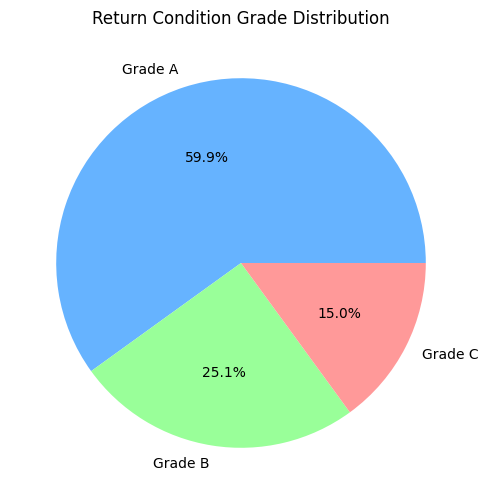

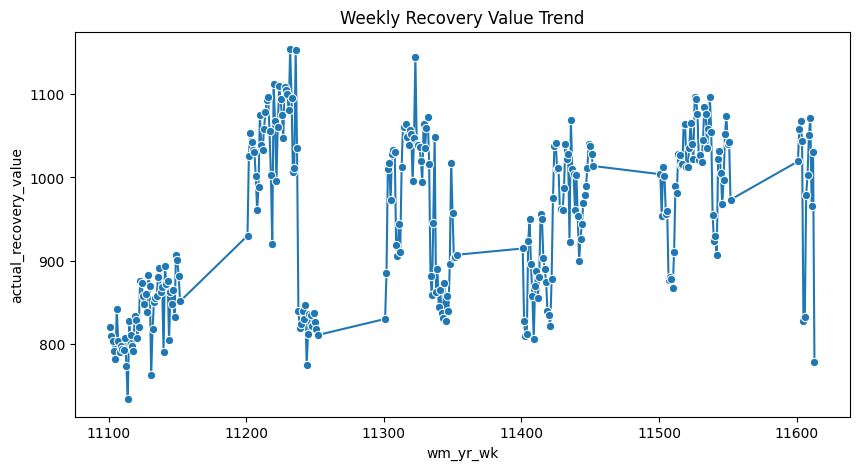

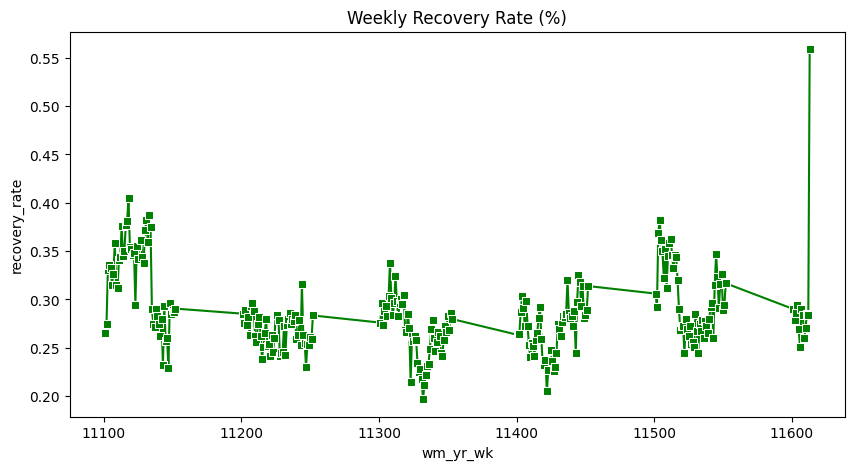

C:\Users\kbatr\AppData\Local\Temp\ipykernel_15644\111366940.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=recovery_comparison, x='scenario', y='recovery_value', palette='viridis')


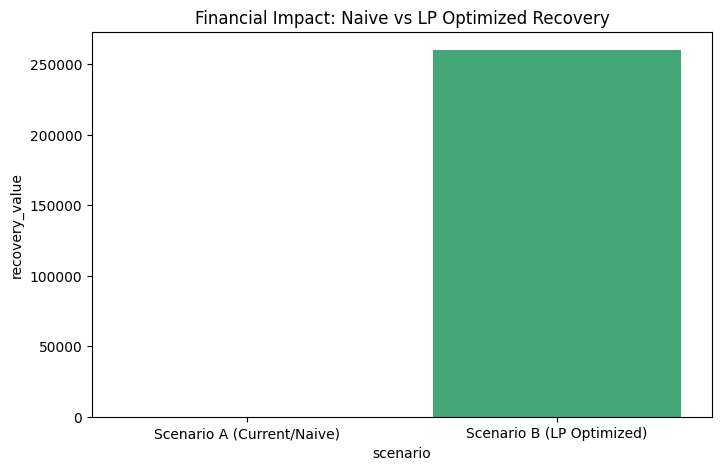


REVERSE LOGISTICS FINAL SUMMARY
Total Returns: 523,574 units
Total Recovery Value: $260,127.93
Recovery Rate: 27.96%
Write-Off Value: $670,107.32
Financial Benefit Generated: $260,127.93


In [14]:
# --- VISUALIZATIONS ---
# 1. Grade Distribution
plt.figure(figsize=(6,6))
returns_data['condition_grade'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#99ff99','#ff9999'])
plt.title('Return Condition Grade Distribution')
plt.savefig('grade_distribution.png')
plt.show()

# 2. Recovery Value by Week
plt.figure(figsize=(10,5))
sns.lineplot(data=returns_kpis, x='wm_yr_wk', y='actual_recovery_value', marker='o')
plt.title('Weekly Recovery Value Trend')
plt.savefig('recovery_value_trend.png')
plt.show()

# 3. Recovery Rate by Week
plt.figure(figsize=(10,5))
sns.lineplot(data=returns_kpis, x='wm_yr_wk', y='recovery_rate', marker='s', color='green')
plt.title('Weekly Recovery Rate (%)')
plt.savefig('recovery_rate_trend.png')
plt.show()

# 4. Scenario Comparison
plt.figure(figsize=(8,5))
sns.barplot(data=recovery_comparison, x='scenario', y='recovery_value', palette='viridis')
plt.title('Financial Impact: Naive vs LP Optimized Recovery')
plt.savefig('recovery_comparison.png')
plt.show()

# Final Print Summary
dash = reverse_logistics_dashboard.iloc[0]
print("\n" + "="*30)
print("REVERSE LOGISTICS FINAL SUMMARY")
print("="*30)
print(f"Total Returns: {dash['Total Returns']:,.0f} units")
print(f"Total Recovery Value: ${dash['Recovery Value']:,.2f}")
print(f"Recovery Rate: {dash['Recovery Rate']:.2%}")
print(f"Write-Off Value: ${dash['Write-Off Value']:,.2f}")
print(f"Financial Benefit Generated: ${dash['Financial Benefit']:,.2f}")
print("="*30)

In [13]:
returns_kpis.to_csv('returns_kpis.csv')